In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os

sns.set_theme(style="white")

# Global sample window size in ms for binning measurements
sample_window_size = 1000
# Rolling window size for smoothing (number of bins)
rolling_window = 5

group_cols = ["query", "bufferSizeInBytes", "buffersInGlobalBufferManager", "joinStrategy",
              "numberOfEntriesSliceCaches", "numberOfWorkerThreads", "pageSize"]
config_cols = [c for c in group_cols if c not in ("query", "numberOfWorkerThreads")]

# Colors
color_analytical = "#7402d8"  # purple
color_statistics = "#ba9344"  # gold/brown

output_dir = "."


def smooth_and_bin(df, time_col, value_col, bin_size=sample_window_size, rolling_win=rolling_window):
    """Bin data by time and apply rolling average for smoothing."""
    result = df.copy()
    result["time_bin"] = (result[time_col] // bin_size) * bin_size
    binned = result.groupby("time_bin", as_index=False)[value_col].mean()
    binned[value_col] = binned[value_col].rolling(window=rolling_win, min_periods=1).mean()
    return binned

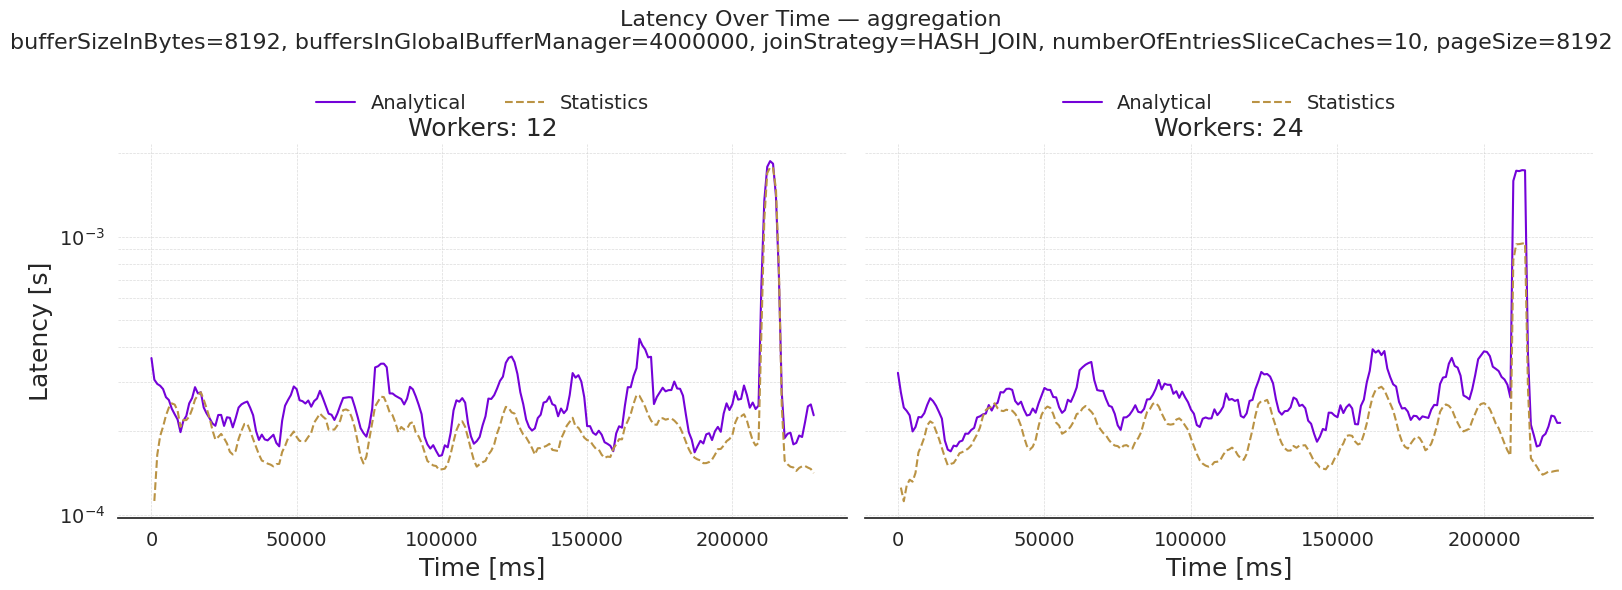

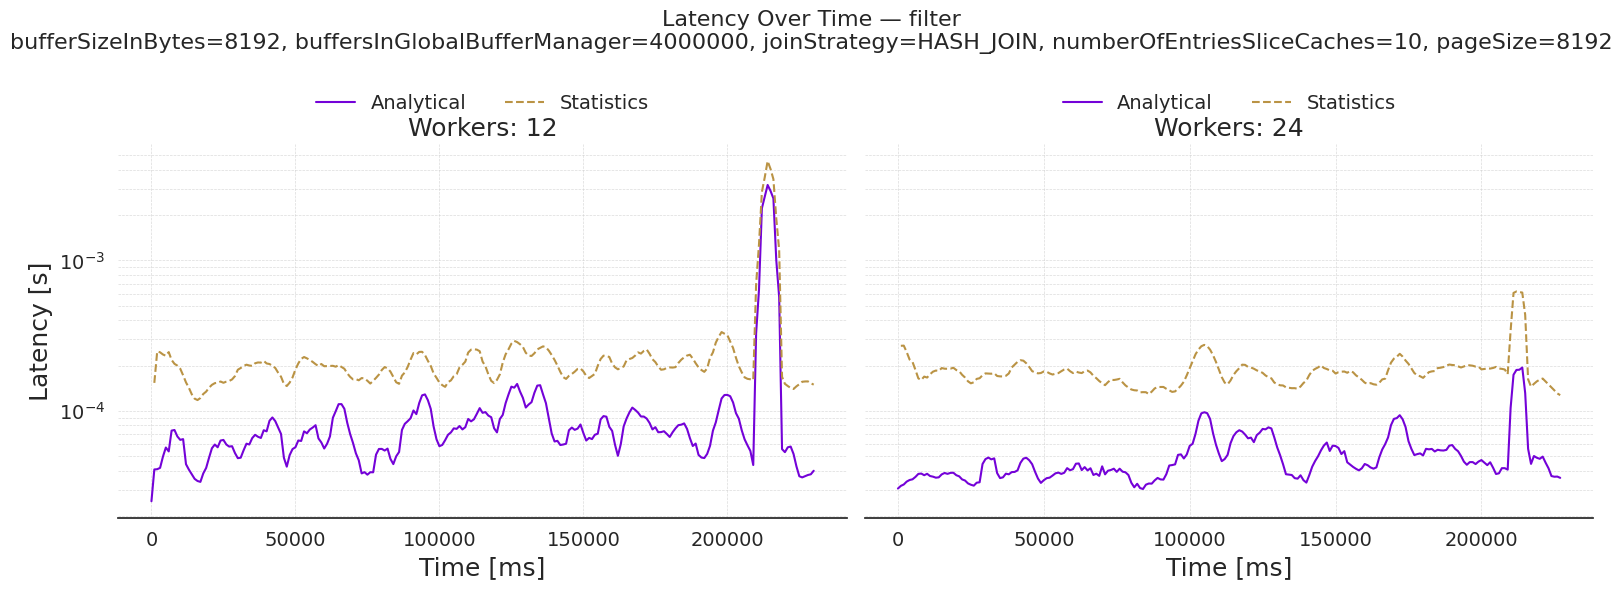

In [13]:
df = pd.read_csv("../../../../latency_results_nebulastream_concat.csv")

invalid_modes = df[df["executionMode"] != "COMPILER"]["executionMode"].unique()
assert len(invalid_modes) == 0, f"Found non-COMPILER execution modes in latency data: {invalid_modes}"

for query_kind in df["query"].unique():
    query_df = df[df["query"] == query_kind]

    for config_key, config_df in query_df.groupby(config_cols):
        config = dict(zip(config_cols, config_key if isinstance(config_key, tuple) else [config_key]))
        config_str = ", ".join(f"{k}={v}" for k, v in config.items())

        thread_values = sorted(config_df["numberOfWorkerThreads"].unique())
        n = len(thread_values)
        ncols = min(n, 3)
        nrows = (n + ncols - 1) // ncols

        fig, axes = plt.subplots(nrows, ncols, figsize=(8 * ncols, 6 * nrows), sharey=True, squeeze=False)
        fig.subplots_adjust(top=0.85, bottom=0.15)

        for idx, n_workers in enumerate(thread_values):
            row, col = divmod(idx, ncols)
            ax = axes[row][col]
            thread_df = config_df[config_df["numberOfWorkerThreads"] == n_workers]

            for qt, color, label, ls in [
                ("ANALYTICAL", color_analytical, "Analytical", "solid"),
                ("STATISTICS", color_statistics, "Statistics", "--"),
            ]:
                type_df = thread_df[thread_df["query_type"] == qt]
                if type_df.empty:
                    continue
                binned = smooth_and_bin(type_df, "normalized_start_timestamp", "latency")
                ax.plot(binned["time_bin"], binned["latency"], color=color, linestyle=ls,
                        label=label, linewidth=1.5)

            ax.set_title(f"Workers: {n_workers}", fontsize=18)
            ax.set_xlabel("Time [ms]", fontsize=18)
            if col == 0:
                ax.set_ylabel("Latency [s]", fontsize=18)
            ax.set_yscale("log")
            ax.tick_params(labelsize=14)
            ax.grid(True, which="both", linestyle="--", linewidth=0.5, alpha=0.7)
            ax.legend(fontsize=14, loc="upper center", bbox_to_anchor=(0.5, 1.18),
                      ncol=2, frameon=False)
            sns.despine(ax=ax, left=True)

        # Hide unused axes
        for idx in range(n, nrows * ncols):
            row, col = divmod(idx, ncols)
            axes[row][col].set_visible(False)

        fig.suptitle(f"Latency Over Time — {query_kind}\n{config_str}",
                     fontsize=16, y=0.98)
        plt.tight_layout()
        plt.savefig(os.path.join(output_dir, f"{query_kind}_latency_subplots.pdf"))
        plt.show()

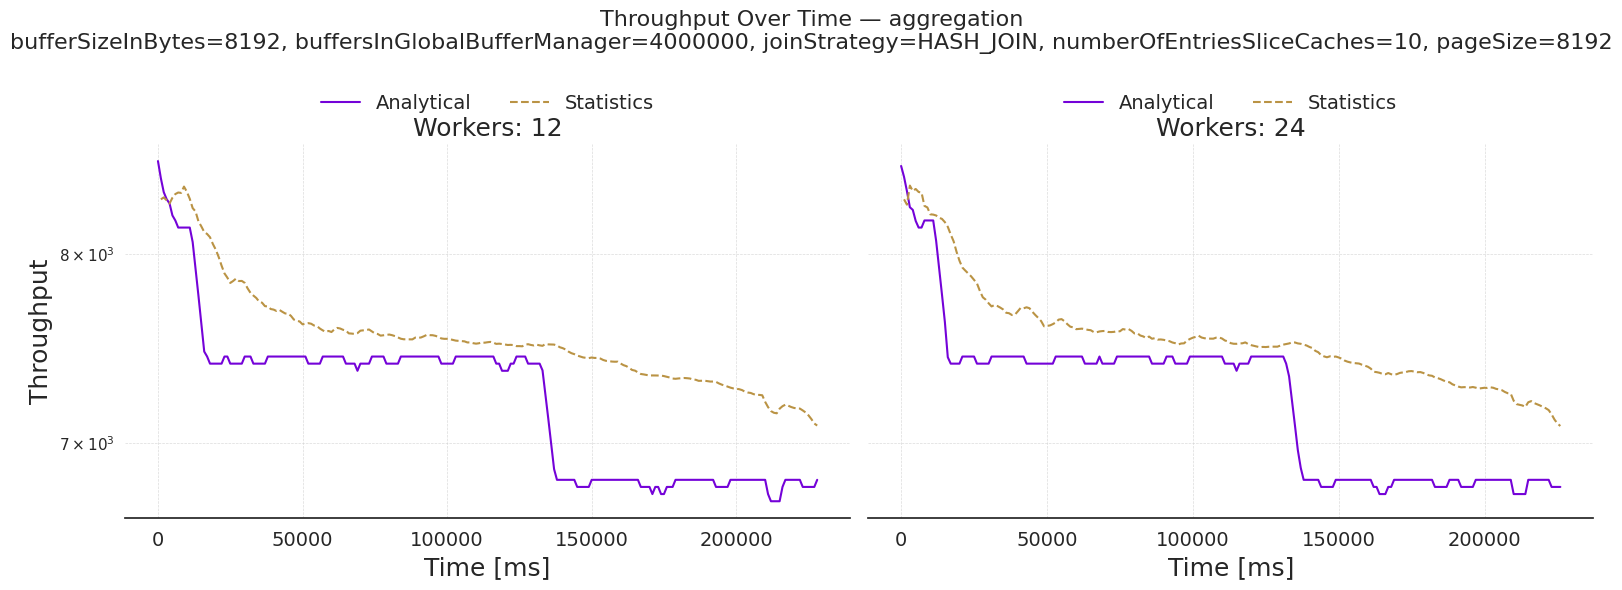

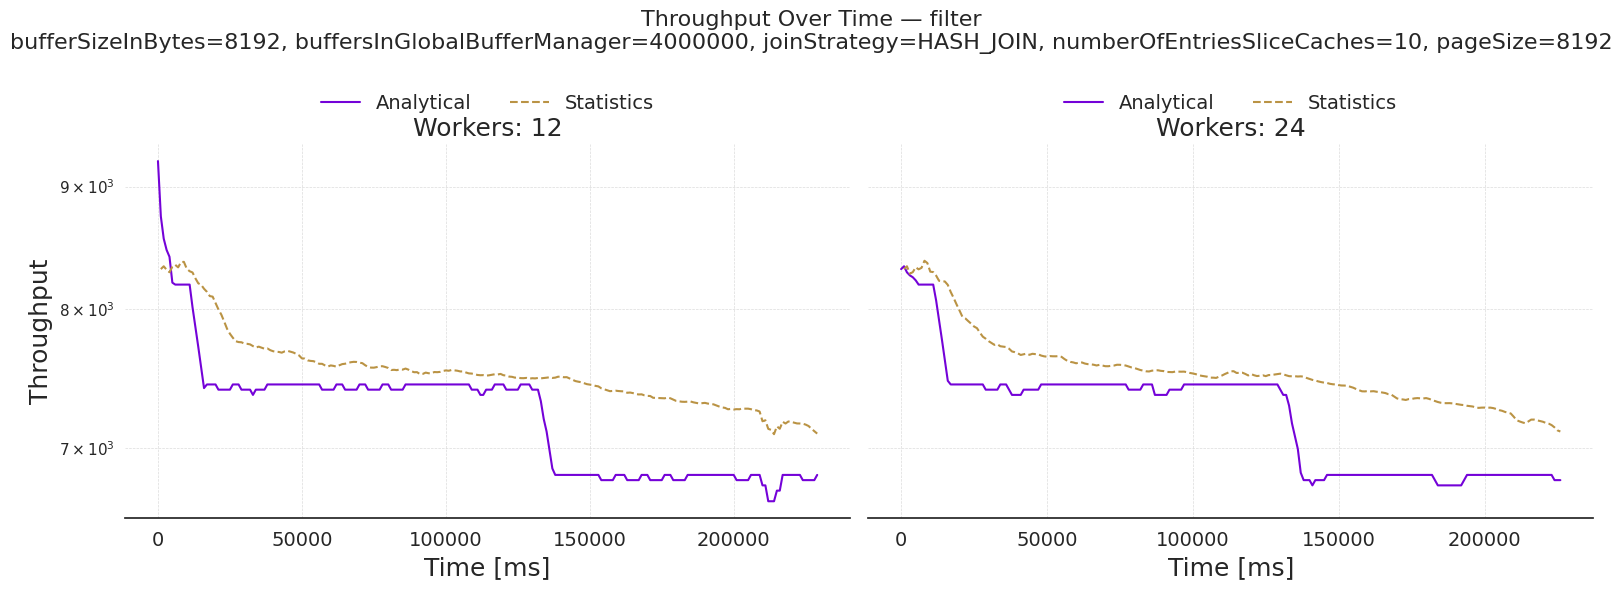

In [14]:
throughput_df = pd.read_csv("../../../../throughput_results_nebulastream_concat.csv")

invalid_modes = throughput_df[throughput_df["executionMode"] != "COMPILER"]["executionMode"].unique()
assert len(invalid_modes) == 0, f"Found non-COMPILER execution modes in throughput data: {invalid_modes}"

for query_kind in throughput_df["query"].unique():
    query_df = throughput_df[throughput_df["query"] == query_kind]

    for config_key, config_df in query_df.groupby(config_cols):
        config = dict(zip(config_cols, config_key if isinstance(config_key, tuple) else [config_key]))
        config_str = ", ".join(f"{k}={v}" for k, v in config.items())

        thread_values = sorted(config_df["numberOfWorkerThreads"].unique())
        n = len(thread_values)
        ncols = min(n, 3)
        nrows = (n + ncols - 1) // ncols

        fig, axes = plt.subplots(nrows, ncols, figsize=(8 * ncols, 6 * nrows), sharey=True, squeeze=False)
        fig.subplots_adjust(top=0.85, bottom=0.15)

        for idx, n_workers in enumerate(thread_values):
            row, col = divmod(idx, ncols)
            ax = axes[row][col]
            thread_df = config_df[config_df["numberOfWorkerThreads"] == n_workers]

            for qt, color, label, ls in [
                ("ANALYTICAL", color_analytical, "Analytical", "solid"),
                ("STATISTICS", color_statistics, "Statistics", "--"),
            ]:
                type_df = thread_df[thread_df["query_type"] == qt]
                if type_df.empty:
                    continue
                binned = smooth_and_bin(type_df, "normalized_timestamp", "throughput")
                ax.plot(binned["time_bin"], binned["throughput"], color=color, linestyle=ls,
                        label=label, linewidth=1.5)

            ax.set_title(f"Workers: {n_workers}", fontsize=18)
            ax.set_xlabel("Time [ms]", fontsize=18)
            if col == 0:
                ax.set_ylabel("Throughput", fontsize=18)
            ax.set_yscale("log")
            ax.tick_params(labelsize=14)
            ax.grid(True, which="both", linestyle="--", linewidth=0.5, alpha=0.7)
            ax.legend(fontsize=14, loc="upper center", bbox_to_anchor=(0.5, 1.18),
                      ncol=2, frameon=False)
            sns.despine(ax=ax, left=True)

        # Hide unused axes
        for idx in range(n, nrows * ncols):
            row, col = divmod(idx, ncols)
            axes[row][col].set_visible(False)

        fig.suptitle(f"Throughput Over Time — {query_kind}\n{config_str}",
                     fontsize=16, y=0.98)
        plt.tight_layout()
        plt.savefig(os.path.join(output_dir, f"{query_kind}_throughput_subplots.pdf"))
        plt.show()